In [1]:
# ===== CLEAR GPU MEMORY =====
import gc
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

gc.collect()
torch.cuda.empty_cache()

device = torch.device('cuda')
print("GPUs available:", torch.cuda.device_count())

# ==========================================
# 1. DATASET LOAD
# ==========================================
class PreCroppedPatchDataset(Dataset):
    def __init__(self, split_dir, mask_base_dir):
        self.img_dir = split_dir
        self.fs_dir = os.path.join(mask_base_dir, 'fastsam')
        self.gt_dir = os.path.join(mask_base_dir, 'gt')
        self.img_files = [f for f in os.listdir(self.img_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_name = self.img_files[idx]
        mask_name = img_name.replace('.jpg', '.png')
        
        img = cv2.imread(os.path.join(self.img_dir, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        fs_mask = cv2.imread(os.path.join(self.fs_dir, mask_name), cv2.IMREAD_GRAYSCALE)
        gt_mask = cv2.imread(os.path.join(self.gt_dir, mask_name), cv2.IMREAD_GRAYSCALE)
        
        img_tensor = torch.from_numpy(img.astype(np.float32) / 255.0).permute(2, 0, 1)
        fs_tensor = torch.from_numpy((fs_mask > 127).astype(np.float32)).unsqueeze(0)
        gt_tensor = torch.from_numpy((gt_mask > 127).astype(np.float32)).unsqueeze(0)
        
        return img_tensor, fs_tensor, gt_tensor

base_path = "/kaggle/input/datasets/deban9017/aip-proj/dat_patch"
train_dataset = PreCroppedPatchDataset(
    os.path.join(base_path, "train"),
    os.path.join(base_path, "train_masks")
)

train_loader = DataLoader(
    train_dataset, batch_size=96, shuffle=True, num_workers=2, pin_memory=True
)

# ==========================================
# 2. MODEL & LOSS CLASSES
# ==========================================
class ResBlock(nn.Module):
    def __init__(self, channels, dilation=1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=dilation, dilation=dilation)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        return x + self.conv2(self.relu(self.conv1(x)))

# Standard Iter 7 Puller
class BoundaryPuller(nn.Module):
    def __init__(self):
        super().__init__()
        self.img_stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.ReLU(inplace=True)
        )
        self.mask_stem = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1), nn.ReLU(inplace=True)
        )
        self.pre_loop = nn.Sequential(
            nn.Conv2d(24, 24, kernel_size=3, padding=1), nn.ReLU(inplace=True)
        )
        self.looper = nn.Sequential(
            ResBlock(24, dilation=1),
            ResBlock(24, dilation=2),
            ResBlock(24, dilation=4),
            nn.Conv2d(24, 1, kernel_size=3, padding=1)
        )
        
        # # Zero-init to prevent random jumping at the start
        # nn.init.constant_(self.looper[-1].weight, 0)
        # nn.init.constant_(self.looper[-1].bias, 0)

    def forward(self, img, init_mask, iters=3):
        img_feats = self.img_stem(img)
        curr_logits = (init_mask - 0.5) * 2.0 

        for _ in range(iters):
            curr_mask = torch.sigmoid(curr_logits)
            mask_feats = self.mask_stem(curr_mask)
            x = torch.cat([img_feats, mask_feats], dim=1)
            x = self.pre_loop(x)
            delta = self.looper(x)
            curr_logits = curr_logits + delta
            
        return torch.sigmoid(curr_logits)

# Standard Iter 7 Smoother
class BoundarySmoother(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(4, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, kernel_size=3, padding=1)
        )

    def forward(self, img, mask):
        x = torch.cat([img, mask], dim=1)
        logits = self.net(x)
        return torch.sigmoid(logits)


# THE NEW MAGNETIC LOSS
class PullerLoss(nn.Module):
    def __init__(self, blur_kernel=11, magnetic_weight=5.0):
        super().__init__()
        self.blur_kernel = blur_kernel
        self.mag_w = magnetic_weight

    def extract_boundary(self, mask):
        # mask is [B, 1, H, W]
        dilated = F.max_pool2d(mask, kernel_size=3, stride=1, padding=1)
        eroded = -F.max_pool2d(-mask, kernel_size=3, stride=1, padding=1)
        return dilated - eroded

    def compute_img_grad(self, img):
        # img is [B, 3, H, W]
        gray = 0.299 * img[:, 0] + 0.587 * img[:, 1] + 0.114 * img[:, 2]
        gray = gray.unsqueeze(1) # Now [B, 1, H, W]
        
        # Sobel filters [Out_ch, In_ch, H, W]
        sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], device=img.device).float().view(1,1,3,3)
        sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], device=img.device).float().view(1,1,3,3)
        
        gx = F.conv2d(gray, sobel_x, padding=1)
        gy = F.conv2d(gray, sobel_y, padding=1)
        
        mag = torch.sqrt(gx**2 + gy**2 + 1e-6)
        
        # Normalize per image in batch to [0, 1]
        b, c, h, w = mag.shape
        mag_max = mag.view(b, c, -1).max(dim=2)[0].view(b, c, 1, 1)
        return mag / (mag_max + 1e-6) # Outputs [B, 1, H, W]

    def forward(self, pred, target, original_img):
        # 1. Base BCE (Pull toward GT)
        gt_boundary = self.extract_boundary(target)
        soft_glow = F.avg_pool2d(gt_boundary, kernel_size=self.blur_kernel, stride=1, padding=self.blur_kernel//2)
        weight_map = 0.2 + (4.8 * (soft_glow / (soft_glow.max() + 1e-6)))
        
        bce = F.binary_cross_entropy(pred, target, reduction='none')
        base_loss = (bce * weight_map).mean()

        # 2. Magnetic Penalty (Penalize placing boundary in flat colors)
        img_grad = self.compute_img_grad(original_img)
        pred_boundary = self.extract_boundary(pred) 
        
        # pred_boundary [B,1,H,W] * (1 - img_grad) [B,1,H,W]
        magnetic_penalty = (pred_boundary * (1.0 - img_grad)).mean()

        return base_loss + (self.mag_w * magnetic_penalty)


# Standard Iter 7 Smoother Loss
class SmoothBoundaryLoss(nn.Module):
    def __init__(self, blur_kernel=31, scatter_weight=2.0):
        super().__init__()
        self.blur_kernel = blur_kernel
        self.scatter_weight = scatter_weight 

    def extract_boundary(self, mask):
        dilated = F.max_pool2d(mask, kernel_size=3, stride=1, padding=1)
        eroded = -F.max_pool2d(-mask, kernel_size=3, stride=1, padding=1)
        return dilated - eroded

    def forward(self, pred, target):
        gt_boundary = self.extract_boundary(target)
        soft_glow = F.avg_pool2d(gt_boundary, kernel_size=self.blur_kernel, stride=1, padding=self.blur_kernel//2)
        glow_norm = soft_glow / (soft_glow.max() + 1e-6)
        
        weight_map = 0.2 + (4.8 * glow_norm)
        bce_loss = F.binary_cross_entropy(pred, target, reduction='none')
        weighted_bce = (bce_loss * weight_map).mean()
        
        local_density = F.avg_pool2d(pred, kernel_size=7, stride=1, padding=3)
        scatter_penalty = pred * (1.0 - local_density)
        hole_penalty = (1.0 - pred) * local_density
        total_density_penalty = scatter_penalty + hole_penalty
        weighted_scatter_loss = (total_density_penalty * weight_map).mean()
        
        return weighted_bce + (self.scatter_weight * weighted_scatter_loss)


# ==========================================
# 3. TRAIN STAGE 1 (THE PULLER)
# ==========================================
print("\n--- STARTING STAGE 1: TRAINING BOUNDARY PULLER ---")
model1 = BoundaryPuller()
if torch.cuda.device_count() > 1:
    model1 = nn.DataParallel(model1)
model1 = model1.to(device)

criterion1 = PullerLoss(blur_kernel=11, magnetic_weight=2)
optimizer1 = optim.Adam(model1.parameters(), lr=1e-3)

scheduler1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer1, mode='min', factor=0.5, patience=2
)

epochs1 = 10
for epoch in range(epochs1):
    model1.train()
    total_loss = 0
    
    for batch_idx, (imgs, fs_masks, gt_masks) in enumerate(train_loader):
        imgs, fs_masks, gt_masks = imgs.to(device), fs_masks.to(device), gt_masks.to(device)
        
        optimizer1.zero_grad()
        iters = random.randint(2, 5)
        m1_preds = model1(imgs, fs_masks, iters)
        
        # INJECTING ORIGINAL IMAGE INTO LOSS FOR ZERO-GRAD PENALTY
        loss = criterion1(m1_preds, gt_masks, imgs)
        
        loss.backward()
        optimizer1.step()
        total_loss += loss.item()
        
        if batch_idx % 20 == 0:
            print(f"M1 Epoch [{epoch}/{epochs1}] Batch [{batch_idx}/{len(train_loader)}] Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    print(f"--- M1 Epoch {epoch} Avg Loss: {avg_loss:.4f} ---")
    
    scheduler1.step(avg_loss)

# Save Model 1
if isinstance(model1, nn.DataParallel):
    torch.save(model1.module.state_dict(), "/kaggle/working/puller_final.pth")
else:
    torch.save(model1.state_dict(), "/kaggle/working/puller_final.pth")

# ==========================================
# 4. CLEAR GPU BEFORE STAGE 2
# ==========================================
print("\nClearing GPU Memory for Stage 2...")
model1.eval() 
optimizer1 = None
criterion1 = None
gc.collect()
torch.cuda.empty_cache()

# ==========================================
# 5. TRAIN STAGE 2 (THE SMOOTHER)
# ==========================================
print("\n--- STARTING STAGE 2: TRAINING BOUNDARY SMOOTHER ---")
model2 = BoundarySmoother()
if torch.cuda.device_count() > 1:
    model2 = nn.DataParallel(model2)
model2 = model2.to(device)

criterion2 = SmoothBoundaryLoss(blur_kernel=31, scatter_weight=2.0)
optimizer2 = optim.Adam(model2.parameters(), lr=1e-3)

scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer2, mode='min', factor=0.5, patience=2
)

epochs2 = 10
for epoch in range(epochs2):
    model2.train()
    total_loss = 0
    
    for batch_idx, (imgs, fs_masks, gt_masks) in enumerate(train_loader):
        imgs, fs_masks, gt_masks = imgs.to(device), fs_masks.to(device), gt_masks.to(device)
        
        with torch.no_grad():
            iters = 4 
            m1_preds = model1(imgs, fs_masks, iters)
            m1_bin = (m1_preds > 0.5).float()
            
        optimizer2.zero_grad()
        m2_preds = model2(imgs, m1_bin)
        
        loss = criterion2(m2_preds, gt_masks)
        loss.backward()
        optimizer2.step()
        total_loss += loss.item()
        
        if batch_idx % 20 == 0:
            print(f"M2 Epoch [{epoch}/{epochs2}] Batch [{batch_idx}/{len(train_loader)}] Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    print(f"--- M2 Epoch {epoch} Avg Loss: {avg_loss:.4f} ---")
    
    scheduler2.step(avg_loss)

# Save Model 2
if isinstance(model2, nn.DataParallel):
    torch.save(model2.module.state_dict(), "/kaggle/working/smoother_final.pth")
else:
    torch.save(model2.state_dict(), "/kaggle/working/smoother_final.pth")

print("\nBoth models trained and saved!")

GPUs available: 2

--- STARTING STAGE 1: TRAINING BOUNDARY PULLER ---
M1 Epoch [0/10] Batch [0/124] Loss: 0.1469
M1 Epoch [0/10] Batch [20/124] Loss: 0.1341
M1 Epoch [0/10] Batch [40/124] Loss: 0.1168
M1 Epoch [0/10] Batch [60/124] Loss: 0.1023
M1 Epoch [0/10] Batch [80/124] Loss: 0.0968
M1 Epoch [0/10] Batch [100/124] Loss: 0.1059
M1 Epoch [0/10] Batch [120/124] Loss: 0.1237
--- M1 Epoch 0 Avg Loss: 0.1118 ---
M1 Epoch [1/10] Batch [0/124] Loss: 0.1063
M1 Epoch [1/10] Batch [20/124] Loss: 0.0905
M1 Epoch [1/10] Batch [40/124] Loss: 0.1038
M1 Epoch [1/10] Batch [60/124] Loss: 0.0982
M1 Epoch [1/10] Batch [80/124] Loss: 0.0982
M1 Epoch [1/10] Batch [100/124] Loss: 0.1055
M1 Epoch [1/10] Batch [120/124] Loss: 0.1158
--- M1 Epoch 1 Avg Loss: 0.1035 ---
M1 Epoch [2/10] Batch [0/124] Loss: 0.0943
M1 Epoch [2/10] Batch [20/124] Loss: 0.1141
M1 Epoch [2/10] Batch [40/124] Loss: 0.1038
M1 Epoch [2/10] Batch [60/124] Loss: 0.1065
M1 Epoch [2/10] Batch [80/124] Loss: 0.0845
M1 Epoch [2/10] Batch

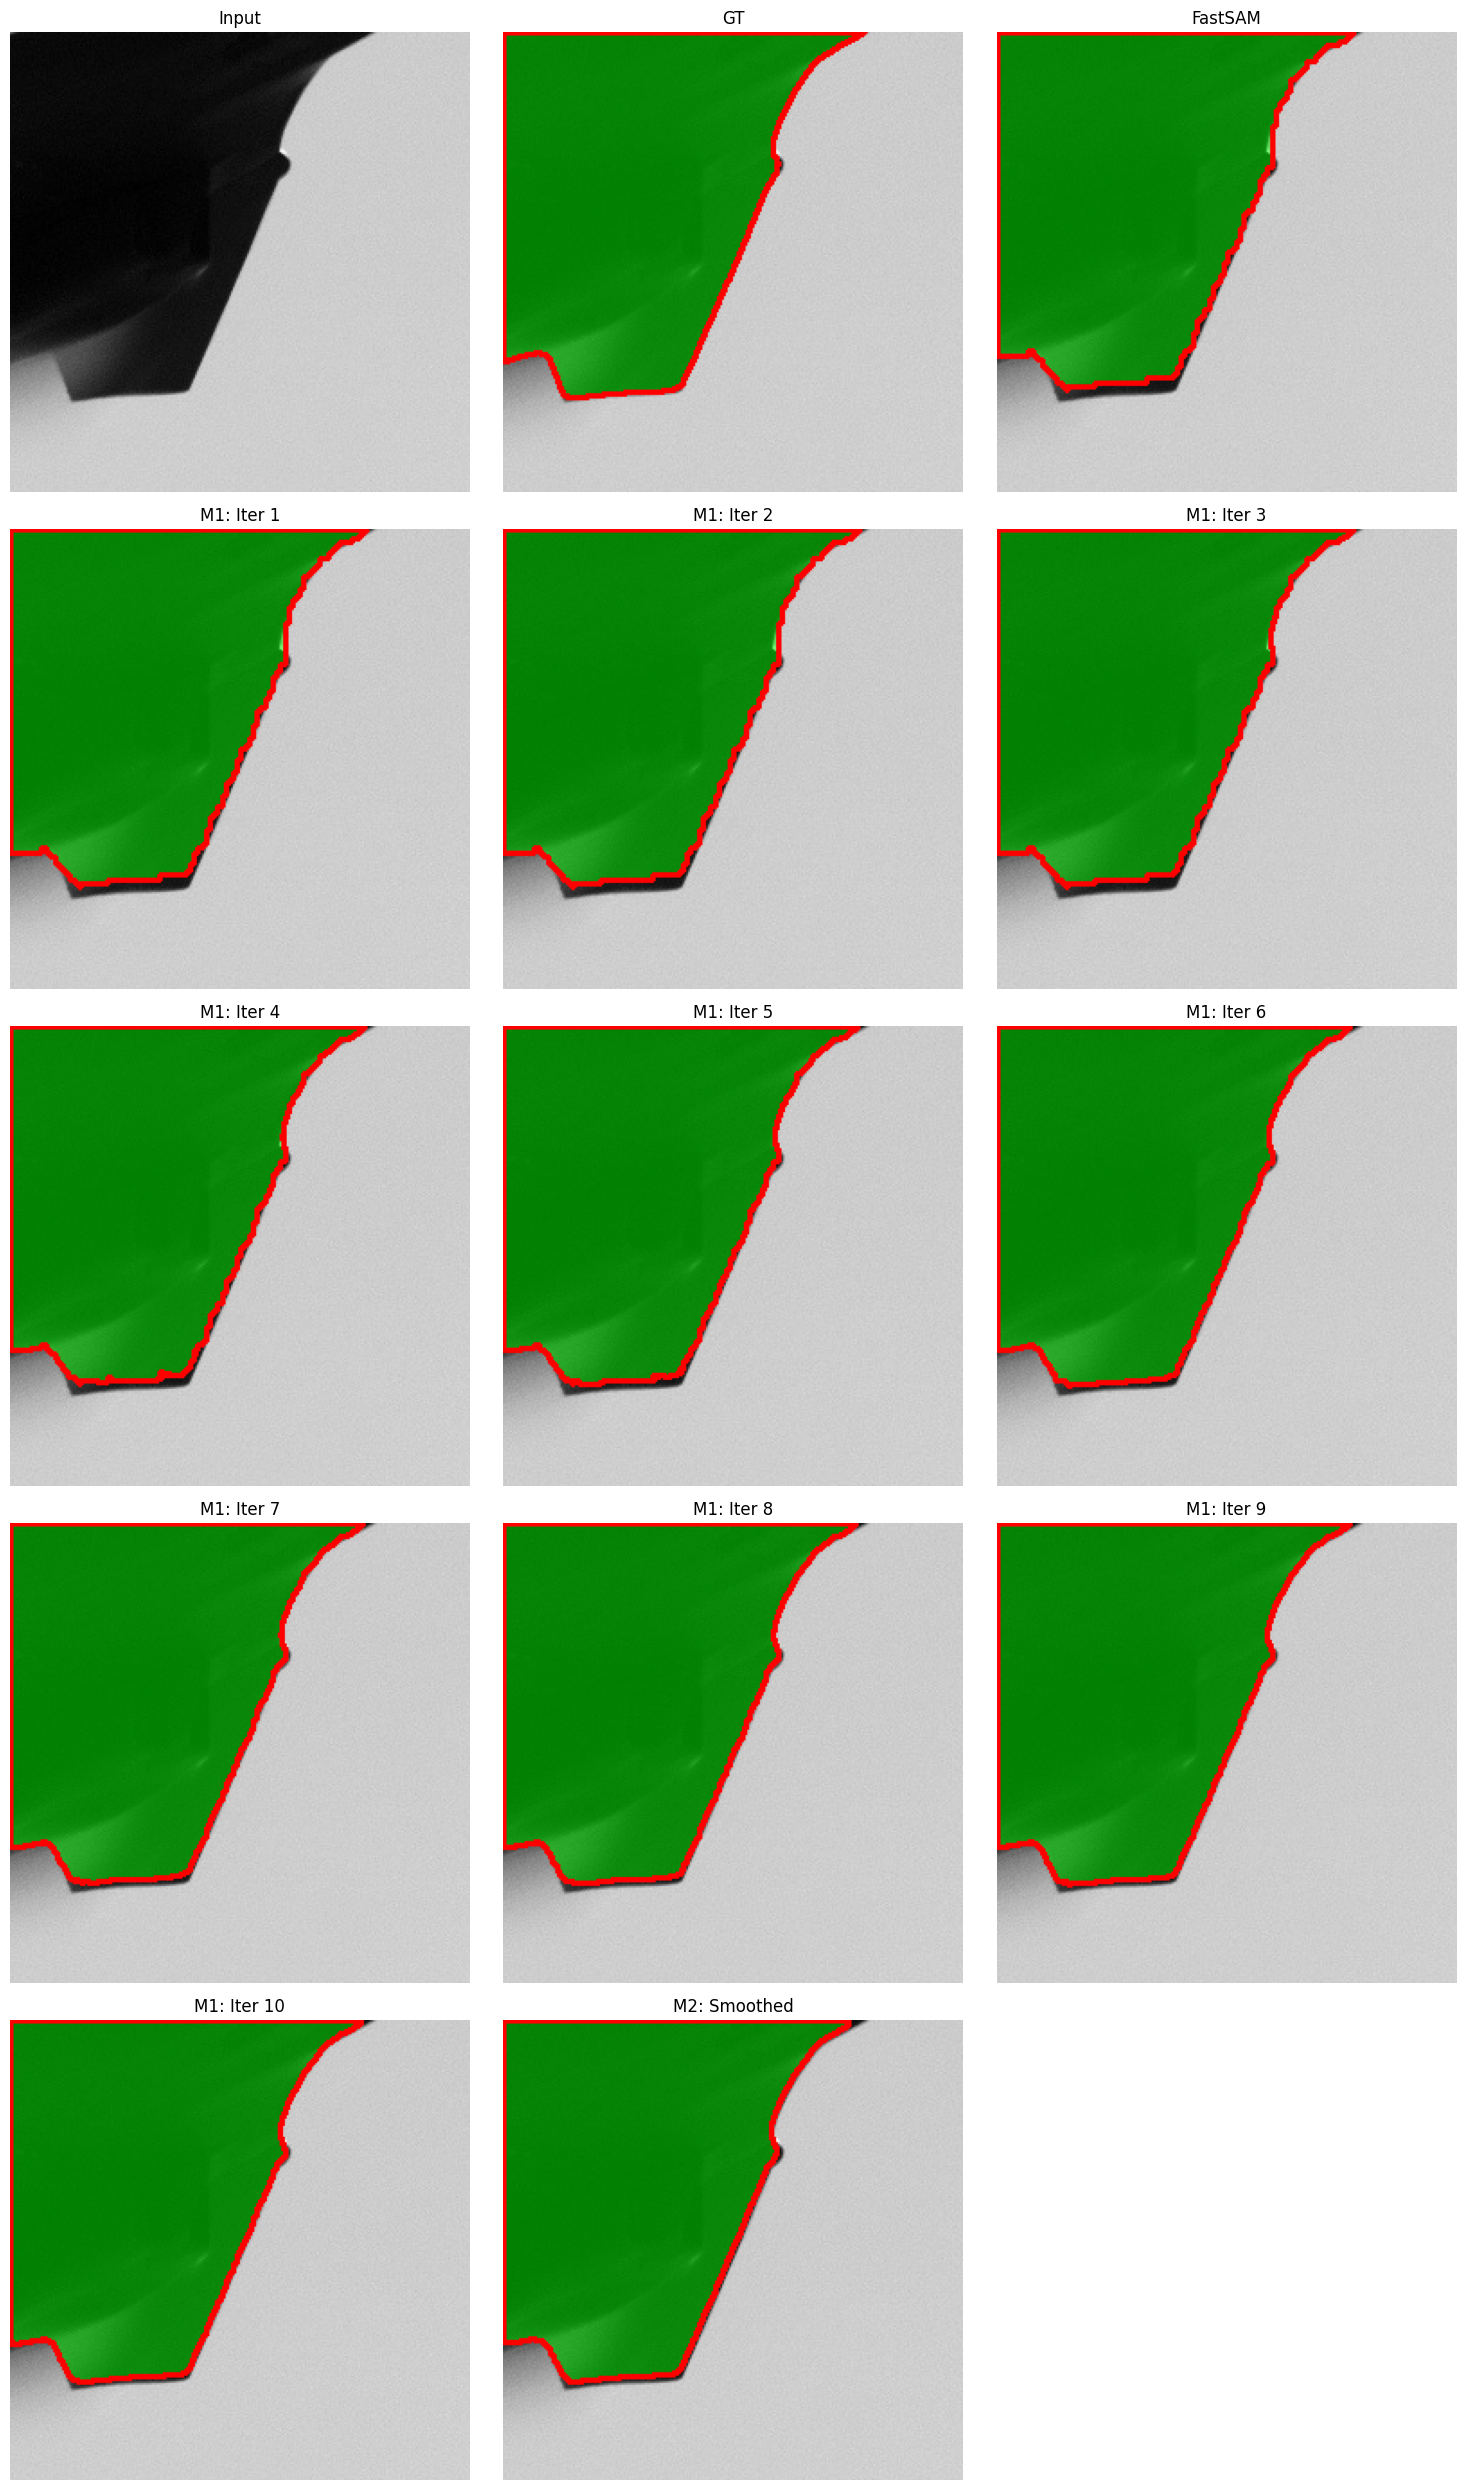

In [2]:
# ==========================================
# 6. VIZ BLOCK
# ==========================================
gc.collect()
torch.cuda.empty_cache()

iters_model1 = 10

def create_overlay(img_base, mask, mask_color=(0, 255, 0)):
    mask_bin = (mask > 0.5).astype(np.uint8)
    color_layer = np.zeros_like(img_base)
    color_layer[:] = mask_color
    
    alpha = mask_bin[..., None] * 0.5 
    overlay = (img_base * (1 - alpha) + color_layer * alpha).astype(np.uint8)
    
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, (255, 0, 0), 2)
    return overlay

device = torch.device('cuda:0')

model1 = BoundaryPuller().to(device)
model1.load_state_dict(torch.load("/kaggle/working/puller_final.pth", map_location=device))
model1.eval()

model2 = BoundarySmoother().to(device)
model2.load_state_dict(torch.load("/kaggle/working/smoother_final.pth", map_location=device))
model2.eval()

test_img_dir = os.path.join(base_path, "val")
test_fs_dir = os.path.join(base_path, "val_masks/fastsam")
test_gt_dir = os.path.join(base_path, "val_masks/gt")

test_imgs = [f for f in os.listdir(test_img_dir) if f.endswith('.jpg')]
img_name = random.choice(test_imgs)
mask_name = img_name.replace('.jpg', '.png')

img = cv2.imread(os.path.join(test_img_dir, img_name))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fs_mask = cv2.imread(os.path.join(test_fs_dir, mask_name), cv2.IMREAD_GRAYSCALE)
gt_mask = cv2.imread(os.path.join(test_gt_dir, mask_name), cv2.IMREAD_GRAYSCALE)

fs_bin = (fs_mask > 127).astype(np.uint8)
gt_bin = (gt_mask > 127).astype(np.uint8)

img_t = torch.from_numpy(img_rgb.astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).to(device)
fs_t = torch.from_numpy(fs_bin.astype(np.float32)).unsqueeze(0).unsqueeze(0).to(device)

m1_step_masks = []

with torch.no_grad():
    for i in range(1, iters_model1 + 1):
        m1_pred_step = model1(img_t, fs_t, iters=i)
        step_out = m1_pred_step.squeeze().cpu().numpy()
        m1_step_masks.append((step_out > 0.5).astype(np.uint8))
        if i == iters_model1:
            m1_bin_t = (m1_pred_step > 0.5).float()
    
    m2_pred_t = model2(img_t, m1_bin_t)
    m2_out = m2_pred_t.squeeze().cpu().numpy()

m2_bin_np = (m2_out > 0.5).astype(np.uint8)

total_plots = 4 + iters_model1 
cols = 3
rows = math.ceil(total_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten() 

axes[0].imshow(img_rgb); axes[0].set_title("Input")
axes[1].imshow(create_overlay(img_rgb, gt_bin)); axes[1].set_title("GT")
axes[2].imshow(create_overlay(img_rgb, fs_bin)); axes[2].set_title("FastSAM")

for i in range(iters_model1):
    ax_idx = 3 + i
    axes[ax_idx].imshow(create_overlay(img_rgb, m1_step_masks[i]))
    axes[ax_idx].set_title(f"M1: Iter {i+1}")

axes[3 + iters_model1].imshow(create_overlay(img_rgb, m2_bin_np))
axes[3 + iters_model1].set_title("M2: Smoothed")

for i in range(total_plots, len(axes)):
    axes[i].axis('off')
    axes[i].set_visible(False)

for ax in axes[:total_plots]:
    ax.axis('off')

plt.tight_layout()
plt.show()